<a href="https://colab.research.google.com/github/faisalkh523/Machine-Learning-Core_Tasks_KodeCamp/blob/main/CIFAR_10_Image_Classification_Task_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Task Objective**

### The CIFAR-10 dataset is a widely used benchmark dataset for image classification. It consists of 60,000 32×32 color images across 10 classes: Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck Unlike MNIST, which contains grayscale handwritten digits, CIFAR-10 is significantly more complex due to:

1. RGB channels (3 instead of 1)
2. Higher visual variability
3. More difficult feature extraction

## You are required to design and implement a Convolutional Neural Network (CNN) that can accurately classify images from the CIFAR-10 dataset. Ensure each step of the process is properly documented using a text block in your notebook just before the code block. Implement your solution in a Jupyter Notebook and submit the link below.



## **Requirements**

1. Load CIFAR-10 using PyTorch built-in datasets.
2. Normalize the dataset properly.
3. Perform an **80% – 20%** train-validation split from the training data.
4. Ensure data is shuffled before splitting.

In [69]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [52]:
# Use a GPU if available.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## CNN Architecture

### At least 3 convolutional layers with each convolutional layer containing:
- A 2D Convolution
- Activation (ReLU)
- Pooling (MaxPooling recommended)
- Apply Dropout to improve generalization.
- Use fully connected layers after the convolution blocks.
- Final layer must use Softmax activation

In [53]:
# CNN architecture (LeNet)
class CIFAR10_CNN(nn.Module):
    def __init__(self):
        super(CIFAR10_CNN, self).__init__()

        # CIFAR-10 = 32x32x3
        # Layer 1
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)

        # pool1 = 16x16x3
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)


        # layer2 = 16x16x32
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        # pool2 = 8x8x32
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)


        # layer3 = 8x8x64
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)

        # pool 3 = 4x4x128
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Dropout
        self.dropout = nn.Dropout(0.5)

        # fully connected layer
        self.fc1 = nn.Linear(128 * 4 * 4, 512)
        self.fc2 = nn.Linear(512, 10)

    def forward(self, x):
        x = self.pool1(torch.relu(self.conv1(x)))  # 32 → 16
        x = self.pool2(torch.relu(self.conv2(x)))  # 16 → 8
        x = self.pool3(torch.relu(self.conv3(x)))  # 8 → 4

        # flatten
        x = x.view(x.size(0), -1)
        x = self.dropout(torch.relu(self.fc1(x)))
        x = self.fc2(x)

        # Softmax
        x = torch.softmax(x, dim=1)
        return x


# Transform: A series of operations to apply to each image and Parameters

In [54]:
batch_size = 64
learning_rate = 0.001
num_epochs = 20

mean = (0.4914, 0.4822, 0.4465)
std  = (0.2470, 0.2435, 0.2616)

# transform data, convert PIL image to PyTorch tensor
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((mean), (std))
])

## Getting the data

In [55]:
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)

In [56]:
# splits dataset into batches and shuffles them
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Load CIFAR-10 using PyTorch built-in datasets.

In [57]:
# Test dataset
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# test DataLoader
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Perform an 80% – 20% train-validation split from the training data.

In [58]:
# 80% – 20% train-validation split
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_data, val_data = random_split(train_dataset, [train_size, val_size])

In [59]:
# Initialize model
model = CIFAR10_CNN().to(device)

# Training components
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=0.0001)

In [60]:
# Training loop
def train(model, device, train_loader, optimizer, criterion, epoch):
    # Set model to training mode.
    model.train()

    train_loss = 0
    correct = 0
    total = 0
    losses = []

    # Loop through batches
    for batch_idx, (data, target) in enumerate(train_loader):
        # data: shape of data (batch_size, 1, 28, 28)
        # target: shape of labels (batch_size,)

        # Move data to the same device as the model (GPU/CPU)
        data, target = data.to(device), target.to(device)

        # Zero the gradients
        optimizer.zero_grad()

        # Forward propagation
        pred = model(data)

        # Loss calculation
        loss = criterion(pred, target)

        # Backward propagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Metrics
        train_loss += loss.item()
        losses.append(loss.item())

        # Get the predicted class (digit with highest score)
        _, predicted = pred.max(1)

        total += target.size(0)  # Add current batch size to total count
        correct += predicted.eq(target).sum().item()  # Add correct predictions to count


        # Print progress every 100 batches
        if batch_idx % 100 == 0:
            print(f'Epoch: {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)} '
                  f'({100. * batch_idx / len(train_loader):.0f}%)]\tLoss: {loss.item():.6f}')


    # Calculate the average metrics
    avg_loss = train_loss / len(train_loader)
    accuracy = 100. * correct / total
    return avg_loss, accuracy, losses

In [61]:
# Test function
def test(model, device, test_loader, criterion):
    # Switch to evaluation mode
    model.eval()

    test_loss = 0
    correct = 0
    total = 0
    losses = []

    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)

            # Forward propagation
            pred = model(data)

            # Loss calculation
            loss = criterion(pred, target)

            # Metrics
            test_loss += loss.item()
            losses.append(loss.item())

            # Calculate accuracy
            _, predicted = pred.max(1)
            total += target.size(0)
            correct += predicted.eq(target).sum().item()

    # Calculate average metrics
    avg_loss = test_loss / len(test_loader)
    accuracy = 100. * correct / total

    print(f"\nTest set: Average loss: {avg_loss:.4f},"
          f"Accuracy: {correct}/{total} ({accuracy:.2f}%)\n")

    return avg_loss, accuracy, losses



In [48]:
# Main training loop

train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

train_losses_epoch_cum = []
test_losses_epoch_cum = []

# Early stopping setup
best_val_loss = float("inf")
patience = 5  # stop if no improvement for 5 epochs
counter = 0
best_epoch = 0


for epoch in range(1, num_epochs + 1):
  train_loss, train_acc, train_losses_epoch = train(model, device, train_loader, optimizer, criterion, epoch)
  test_loss, test_acc, test_losses_epoch = test(model, device, test_loader, criterion)

  train_losses.append(train_loss)
  train_accuracies.append(train_acc)
  train_losses_epoch_cum.extend(train_losses_epoch)

  test_losses.append(test_loss)
  test_accuracies.append(test_acc)
  test_losses_epoch_cum.extend(test_losses_epoch)

  # Early stopping
  if test_loss < best_val_loss:
    best_val_loss = test_loss
    counter = 0
    best_epoch = epoch
    torch.save(model.state_dict(), "best_model.pth")  # Save best weights
  else:
    counter += 1

  if counter >= patience:
    print(f"\nEarly stopping triggered at epoch {epoch}")
    break


print("Training complete!")
print(".." * 60)

Epoch: 1 [0/50000 (0%)]	Loss: 2.303446
Epoch: 1 [6400/50000 (13%)]	Loss: 2.208301
Epoch: 1 [12800/50000 (26%)]	Loss: 2.124611
Epoch: 1 [19200/50000 (38%)]	Loss: 2.062566
Epoch: 1 [25600/50000 (51%)]	Loss: 2.094425
Epoch: 1 [32000/50000 (64%)]	Loss: 2.075041
Epoch: 1 [38400/50000 (77%)]	Loss: 2.035090
Epoch: 1 [44800/50000 (90%)]	Loss: 1.995777

Test set: Average loss: 1.9633,Accuracy: 4953/10000 (49.53%)

Epoch: 2 [0/50000 (0%)]	Loss: 1.966970
Epoch: 2 [6400/50000 (13%)]	Loss: 1.996825
Epoch: 2 [12800/50000 (26%)]	Loss: 1.942492
Epoch: 2 [19200/50000 (38%)]	Loss: 2.038099
Epoch: 2 [25600/50000 (51%)]	Loss: 2.049446
Epoch: 2 [32000/50000 (64%)]	Loss: 1.969033
Epoch: 2 [38400/50000 (77%)]	Loss: 1.974717
Epoch: 2 [44800/50000 (90%)]	Loss: 1.997502

Test set: Average loss: 1.8920,Accuracy: 5683/10000 (56.83%)

Epoch: 3 [0/50000 (0%)]	Loss: 1.900271
Epoch: 3 [6400/50000 (13%)]	Loss: 1.875189
Epoch: 3 [12800/50000 (26%)]	Loss: 1.838998
Epoch: 3 [19200/50000 (38%)]	Loss: 1.925200
Epoch: 3 [25

# VISUALIZE TRAINING RESULTS


Training history saved to training_history.png


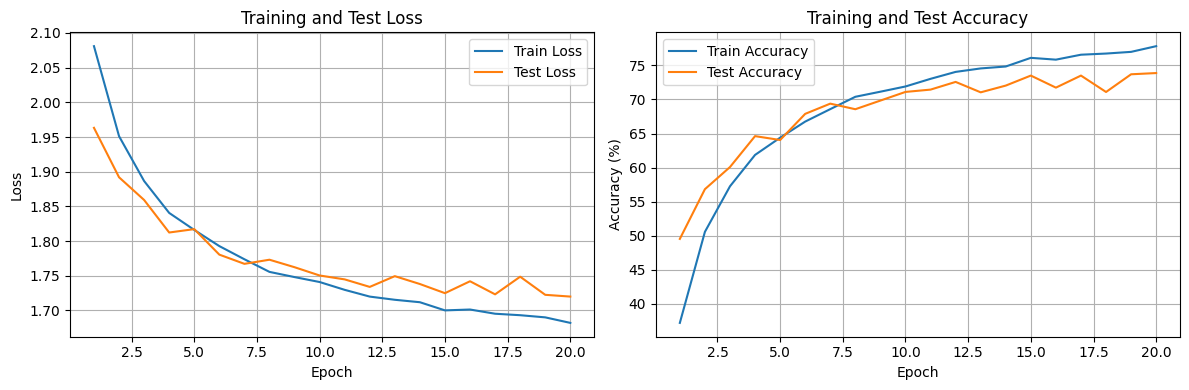

In [49]:
# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# LEFT PLOT: Loss over epochs
# Loss should generally decrease over time
# If test loss starts increasing while train loss decreases, that's overfitting
ax1.plot(range(1, num_epochs + 1), train_losses, label='Train Loss')
ax1.plot(range(1, num_epochs + 1), test_losses, label='Test Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Test Loss')
ax1.legend()
ax1.grid(True)

# RIGHT PLOT: Accuracy over epochs
# Accuracy should generally increase over time
# Large gap between train and test accuracy indicates overfitting
ax2.plot(range(1, num_epochs + 1), train_accuracies, label='Train Accuracy')
ax2.plot(range(1, num_epochs + 1), test_accuracies, label='Test Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training and Test Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()  # Adjust spacing between subplots
plt.savefig('training_history.png')  # Save the figure
print('Training history saved to training_history.png')


# Model Evaluation

In [50]:
# Final Validation Accuracies
print(f"Final Validation Accuracy: {test_accuracies[-1]:.2f}%")

# Best Epoch
print(f"\nBest Epoch: {best_epoch}")

# Optimizer
print(f"\nOptimizer Used: {optimizer.__class__.__name__}")

# Learning rate
print(f"\nLearning Rate: {optimizer.param_groups[0]['lr']}")

# Regularization Techniques Applied
print("\nRegularization Techniques Applied: Dropout, Weight Decay")

Final Validation Accuracy: 73.88%

Best Epoch: 20

Optimizer Used: Adam

Learning Rate: 0.001

Regularization Techniques Applied: Dropout, Weight Decay


# Confusion Matrix
## showing classificstion and Misclassification

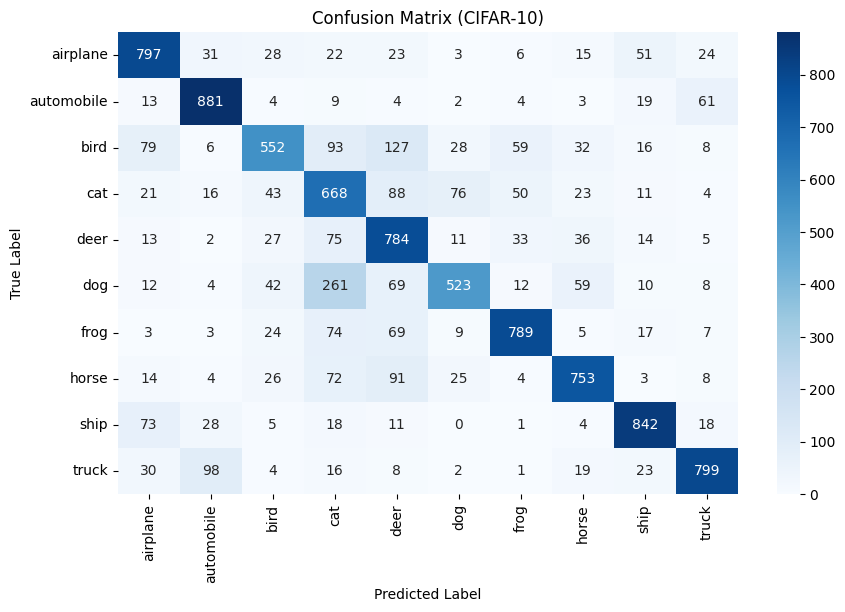

In [80]:
# save the best model
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)

        outputs = model(data)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(target.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)  # confusion  matrix

classes = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck'] # contain in the CIFAR-10 32x32 color image

plt.figure(figsize=(10,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes,
            yticklabels=classes)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (CIFAR-10)")

# display confusion matrix
plt.show()



MIsclassification has high probability in Dog to Cat, in which Dog is confused to a cat. also Bird to deer, etc. as shown in the confusion matrix

# **possible reasons for the misclassifications.**


*   similarity of features between the classes
*   Poor image resolution, which is evident from the images
*   Model may learn background instead of actual image some times





